/tmp/ipykernel_1818/1723879572.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  company_data = yf.download(tickers, period="5y", group_by="tickers")
[*********************100%***********************]  12 of 12 completed
/tmp/ipykernel_1818/1723879572.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_long = company_data.stack(level=0).reset_index()


Test Statistic: 1.542714135899252
P-Value: 1.0
Critical Values: [-3.90485841 -3.34081967 -3.04770405]
        Date  Singtel_Close  Capitaland_Close
0 2021-09-27       2.030535          1.607912
1 2021-09-28       2.030535          1.592451
2 2021-09-29       1.989924          1.600182
3 2021-09-30       2.006169          1.569260
4 2021-10-01       1.989924          1.569260
                            OLS Regression Results                            
Dep. Variable:       Capitaland_Close   R-squared:                       0.922
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                 1.533e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        07:13:38   Log-Likelihood:                 1535.6
No. Observations:                1305   AIC:                            -3067.
Df Residuals:                    1303   BIC:                         

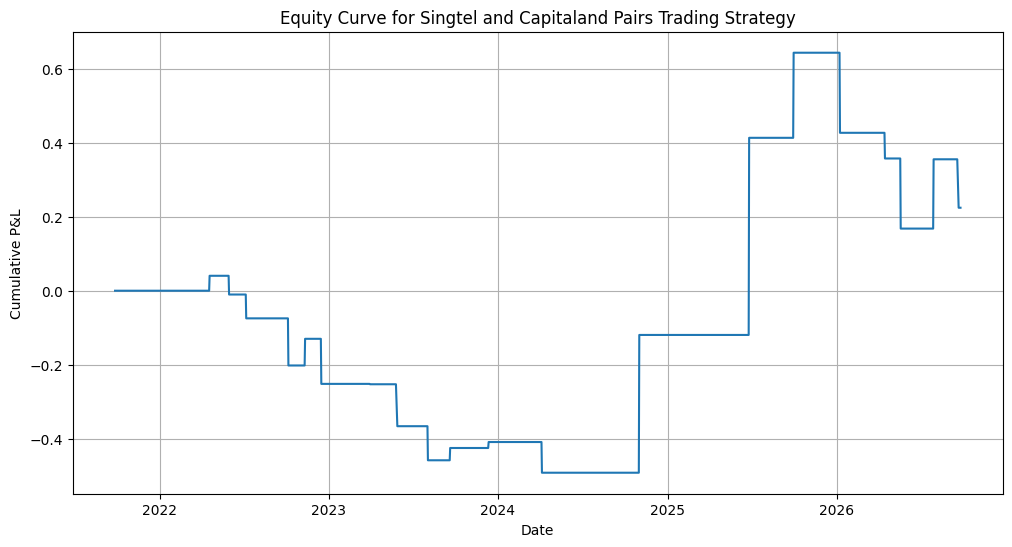

0.22440532833576032
0.22440532833576032
(1244, 13)
Target_Spread_Upwards
1    627
0    617
Name: count, dtype: int64
(870, 3)
(374, 3)
(870,)
(374,)
Accuracy: 0.5347593582887701
              precision    recall  f1-score   support

           0       0.57      0.36      0.44       190
           1       0.52      0.71      0.60       184

    accuracy                           0.53       374
   macro avg       0.54      0.54      0.52       374
weighted avg       0.54      0.53      0.52       374



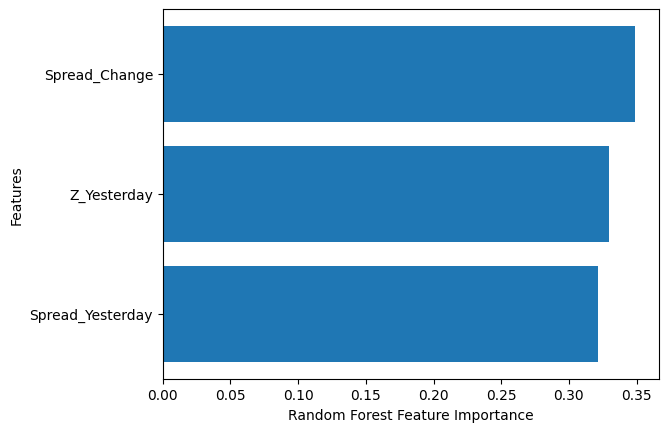

Sharpe Ratio: 0.12157986054163987
          Date         Z  ML_Prediction
930 2025-04-21  3.137304              0
931 2025-04-22  2.896838              1
932 2025-04-23  2.956917              0
933 2025-04-24  2.235297              0
934 2025-04-25  2.643603              0
Final P&L with ML filter: -0.38407466195122575
Sharpe with ML : -0.5893487037292205
Sortino Ratio : 0.04846512002013611
Maximum Drawdown-0.5325671122512333
Bear Days:  260
Recovery Days: 522
Recent Days: 452
Sharpe for Bear: -1.1770927954653316
Sharpe for Recovery: 0.22406061847839234
Sharpe for Recent: 0.37199286234384227


In [11]:
import pandas as pd
import yfinance as yf
from statsmodels.tsa.stattools import coint
from itertools import combinations
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# PHASE 1
#defining tickers for all 12 companies
tickers = ["BN2.SI", "5UL.SI", "VC2.SI", "5E2.SI", "S63.SI", "PCT.SI", "8AZ.SI", "S61.SI", "Z74.SI", "O39.SI", "9CI.SI","C38U.SI"]

#downloading historical data for the companies
company_data = yf.download(tickers, period="5y", group_by="tickers")


#stack tickers into a single column row wise to flatten/reshape the multi index columns when downloading data for banks
df_long = company_data.stack(level=0).reset_index()
df_long.columns = ['Date', 'Ticker', 'Close', 'High', 'Low', 'Open', 'Volume']

#Handling missing trading dates and holidays
#Date is DateTime format
df_long['Date'] = pd.to_datetime(df_long['Date'])


#dates to skip weekends and holidays and only working days for singapore market timeframe
start_date = df_long['Date'].min()
end_date = df_long['Date'].max()
all_business_days = pd.date_range(start=start_date, end=end_date, freq='B')

# Reindex all 3 banks individually to show missing days
cleaned_dfs = []
for ticker in tickers:
  sub_df = df_long[df_long['Ticker'] == ticker].set_index('Date')
  sub_df = sub_df.reindex(all_business_days)
  sub_df['Ticker'] = sub_df['Ticker'].ffill().bfill() #Purpose of filling up Ticker column
  cleaned_dfs.append(sub_df)

# Recombining all data back into one clean long format dataframe
df_Clean = pd.concat(cleaned_dfs).reset_index().rename(columns={'index' : 'Date'})

#Imputation of missing prices and volumns
#Stock prices from current days if missing, will be carried over from previous day's trading price
#Volume on non tradings will = 0
# Sorting data in chronogical order to ensure correct forward filling
df_Clean = df_Clean.sort_values(by=['Ticker', 'Date'])


#Forward fill the price columns [High Low Open Close and Adjusted Close]
price_cols = ['High', 'Low', 'Open', 'Close']
df_Clean[price_cols] = df_Clean.groupby('Ticker')[price_cols].ffill()
df_Clean[price_cols] = df_Clean.groupby('Ticker')[price_cols].bfill()


#Backward fill if any missing values remain at start of dataset
df_Clean['Volume'] = df_Clean.groupby('Ticker')['Volume'].bfill()

#Fill missing Volumes with 0 aka non trading days
df_Clean['Volume'] = df_Clean['Volume'].fillna(0)


# PHASE TWO
#1st PAIR TESTING! TAKE THE ONE WITH THE LOWEST P-VALUE. Extract OCBC and SingTel first.
OCBC_filtered = df_Clean[df_Clean['Ticker'] == 'O39.SI']
SingTel_filtered = df_Clean[df_Clean['Ticker'] == 'Z74.SI']

#Renaming OCBC and SingTel Close Columns
OCBC_filtered = OCBC_filtered.rename(columns={'Close': 'OCBC_Close'})
SingTel_filtered = SingTel_filtered.rename(columns={'Close': 'SingTel_Close'})

#Merging OCBC and Singtel's date
df_merged = pd.merge(OCBC_filtered, SingTel_filtered, on='Date', how='inner')

#Drop missing values
df_merged = df_merged.dropna()

#Run co-integration test on merged SingTel and OCBC data
score, p_value, critical_values = coint(df_merged['OCBC_Close'], df_merged['SingTel_Close'])


print(f"Test Statistic: {score}")
print(f"P-Value: {p_value}")
print(f"Critical Values: {critical_values}")

#OCBC vs SingTel = p-value: 1.0 -> NOT CoIntegrated as test statistic is NOT lower than critical value,
#Test statistic was at 1.4532681731842312 while critical values were at [-3.90485841 -3.34081967 -3.04770405]
#as cointegration means that the 2 stocks despite drifting far apart will eventually come back together but
#OCBC and SingTel does not, p-value stating 1.0 means that it is 100% chance that relationship is purely
#noise hence OCBC and SingTel "failed" this test


# # PHASE THREE

# #Finding list of all possible combinations from 12 tickers
# possible12pairs = list(combinations(tickers, 2))

# #storing possible combinations from 12 tickers into result list
# RESULTpossible12pairs = []

# #looping through EACH pair combination
# for ticker1,ticker2 in possible12pairs:

# #filtering each ticker in df_Clean [TO ONLY KEEP DATE AND CLOSE] IN LOOP
#     df1 = df_Clean[df_Clean['Ticker'] == ticker1][['Date', 'Close']]
#     df2 = df_Clean[df_Clean['Ticker'] == ticker2][['Date', 'Close']]

# #Rename Close columns IN LOOP
#     df1 = df1.rename(columns={'Close': f'{ticker1}_Close'})
#     df2 = df2.rename(columns={'Close': f'{ticker2}_Close'})

# #merge both df1 and df2 date column using inner join IN LOOP
#     merged_df1n2 = pd.merge(df1, df2, on='Date', how='inner')

# #drop columns that have missing values aka NaN IN LOOP
#     final_df = merged_df1n2.dropna()

# #cointegration test for all 12 pairs IN LOOP
#     Score, P_Value, Critical_Values = coint(final_df[f'{ticker1}_Close'], final_df[f'{ticker2}_Close'])


# #Storing result for cointegration
#     RESULTpossible12pairs.append((ticker1, ticker2, Score, P_Value, Critical_Values))

# #Converting stored results into dataframe
# finalresults_df = pd.DataFrame(RESULTpossible12pairs, columns=['Ticker1','Ticker2','Score','P_Value','Critical Values'])

# #Sort by P values ascending order
# finalresults_df = finalresults_df.sort_values('P_Value')

# print(finalresults_df.head())

# #Best pair = Z74.SI (Singtel) and C38U.SI (Capitaland Integrated Commercial Trust)
# #P Value = 0.000239 -> Strongest Cointegration evidence
# #2nd best pair = S63.SI (ST Engineering) and C38U.SI (Capitaland Integrated Commercial Trust)
# #P Value = 0.008193 -> Cointegration


# PHASE FOUR

#Extracting both Singtel and Capitaland Integrated Commercial Trust from Df_Clean
Singtel = df_Clean[df_Clean['Ticker'] == 'Z74.SI'][['Date','Close']].copy()
Capitaland = df_Clean[df_Clean['Ticker'] == 'C38U.SI'][['Date','Close']].copy()

#Renaming of Close columns for both Singtel and Capitaland
singtel = Singtel.rename(columns={'Close': 'Singtel_Close'})
capitaland = Capitaland.rename(columns={'Close': 'Capitaland_Close'})

#Merging both Singtel and Capitaland's Date
pair_df = pd.merge(singtel, capitaland, on="Date", how="inner")

#Dropping Null values
pair_df = pair_df.dropna()

print(pair_df.head())


#Finding OLS regression -> finding the line that minimizes distance between itself
#and every data point dots. dots are daily prices of singtel and capitaland
#plotted against each other. Line is to find the best relationship, eg if Capitaland goes
#up by $1 how much does Singtel goes up

X = pair_df['Singtel_Close']
y = pair_df['Capitaland_Close']

# Using Singtel as the independent variable (X) to calculate the hedge ratio (slope) and the intercept.
# [Simply put: The intercept is the baseline price gap between the two stocks when Singtel is ignored.]
X_with_constant = sm.add_constant(X)

#Fit/Training OLS model
model = sm.OLS(y, X_with_constant)
results = model.fit()

print(results.summary())


# Results from OLS regression important things to note:
# R squared value is at 0.921 indicates CapitaLand's daily price movements over the last 5 years can be directly explained by Singtel's price movements.
# Singtel_Close coefficient is 0.2684, indicating for every $1 Singtel moves up Capitaland moves up $0.27 [HEDGE RATIO]
# However the reverse is also true, meaning if i were to buy 1k capitaland shares (y), i would then need to sell 268 Singtel shares (X)
# const aka intercept is at 1.0795 meaning even if Singtel drops to $0, Capitaland remains at $1.08 [BASELINE PRICE GAP]
# P>|t| is 0 for both, meaning mathematically is relationship is solid
# Durbin-Watson is at 0.077 meaning that there is a sign of heavy "autocorrelation" (meaning today's price is highly dependent on yesterday's price)

#formula to calculate spread [aka price gap] between Singtel and Capitaland
# SPREAD = My Asset - (Hedge Ratio * Baseline Asset) - Baseline Price Gap
pair_df['Spread'] = pair_df['Singtel_Close'] - (0.2684 * pair_df['Capitaland_Close']) - 1.0795

print(pair_df[['Date','Singtel_Close','Capitaland_Close','Spread']].head())


# Finding the rolling/noving average/mean and SD of Spread
pair_df['Spread_Rolling_Mean'] = pair_df['Spread'].rolling(window=60).mean()
pair_df['Spread_Rolling_Std'] = pair_df['Spread'].rolling(window=60).std()

# Print out Spread's rolling mean and SD
print(pair_df[['Date','Singtel_Close','Capitaland_Close','Spread','Spread_Rolling_Mean','Spread_Rolling_Std']].head(100))

# Calculating Z-Score aka many standard deviations a data point is from the mean (average)
pair_df['Z'] = (pair_df['Spread'] - pair_df['Spread_Rolling_Mean']) / pair_df['Spread_Rolling_Std']


print(pair_df[['Date', 'Spread', 'Spread_Rolling_Mean', 'Spread_Rolling_Std', 'Z']].head())
print(pair_df[['Date', 'Spread', 'Spread_Rolling_Mean', 'Spread_Rolling_Std', 'Z']].tail())
print(pair_df['Z'].describe())


# Total Information thus far
# Hedge Ratio or Beta = 0.2684
# Intercept or alpha = 1.0795
# Z-score stats:
# mean = 0.511995 [the Spread is slightly positive]
# std = 1.253853
# min = -2.957101 [When Capitaland was most expensive vs Singtel]
# max = 4.549384 [When Singtel was most expensive vs Capitaland]


# Backtesting Loop for both Singtel and Capitaland

position = 0
entry_singtel = 0
entry_capitaland = 0
pnl = 0
cumulative_pnl = 0
pnl_list = []
cost = 0.001

for i in range(len(pair_df)):
  z = pair_df['Z'].iloc[i]
  singtel_price = pair_df['Singtel_Close'].iloc[i]
  capitaland_price = pair_df['Capitaland_Close'].iloc[i]

  # if no position and z > 2, open short Singtel
  if position == 0 and z > 2:
    position = 1
    entry_singtel = singtel_price

  # if no position and z < 2,  open short Capitaland
  if position == 0 and z < -2:
    position = -1
    entry_capitaland = capitaland_price

  # if in position and z crosses 0: Close short Singtel
  if position == 1 and z <=0:
    pnl = singtel_price - entry_singtel
    cumulative_pnl += pnl - cost
    position = 0

  # Close short Capitaland
  if position == -1 and z >= 0:
      pnl = capitaland_price - entry_capitaland
      cumulative_pnl += pnl - cost
      position = 0

# Append cumulative P&L every day
  pnl_list.append(cumulative_pnl)


print(len(pnl_list))
print(pnl_list[-1])
# Final P&L before cost: 0.2444 over 1305 days/~5 years

pair_df['Cumulative_PnL'] = pnl_list

print(pair_df[['Date','Singtel_Close','Capitaland_Close','Spread','Z','Cumulative_PnL']].head())
print(pair_df[['Date','Singtel_Close','Capitaland_Close','Spread','Z','Cumulative_PnL']].tail())

# Plot Equity Curve
plt.figure(figsize=(12, 6))
plt.plot(pair_df['Date'], pair_df['Cumulative_PnL'])
plt.title('Equity Curve for Singtel and Capitaland Pairs Trading Strategy')
plt.xlabel('Date')
plt.ylabel('Cumulative P&L')
plt.grid(True)
plt.show()


# Equity Curve shows us that it remains 0 from 2022 till mid 2022 where there
# was a slight upward before going slowly down until late 2024, after which
# the trade went up to above 0.6 at the start of 2026 before slowly dropping
# slowly to 0.1++ and slowly going back up to 0.2+ as of current date

# Before transactional cost, profit is at 0.2444 over 1305 days
# Subtracting transactional costs (0.1% per trade)

print(pnl_list[-1])

# Final profit after cost = 0.2244 over 1305 days
# Costs reduced profit from 0.2444 to 0.2244 (Estimated ~8% reduction)

print(pair_df['Cumulative_PnL'].iloc[-1])

# Summarisation for Backtesting
# Final P&L after costs 0.2244 over 1305 days
# Cost reduced profit by ~8% from 0.2444 to 0.2244


# PHASE FIVE

#feature engineering
pair_df['Spread_Yesterday'] = pair_df['Spread'].shift(1)
pair_df['Z_Yesterday'] = pair_df['Z'].shift(1)
pair_df['Spread_Change'] = pair_df['Spread'] - pair_df['Spread_Yesterday']
pair_df['Spread_Tomorrow'] = pair_df['Spread'].shift(-1)
pair_df['Target_Spread_Upwards'] = (pair_df['Spread_Tomorrow'] > pair_df['Spread']).astype(int) # converting true and false into 1s and 0s

# dropping NaN datas
pair_df = pair_df.dropna()

# counting how many 1s and 0s are in our Target_Spread_Upward
pair_df['Target_Spread_Upwards'].value_counts()

print(pair_df.shape)
print(pair_df['Target_Spread_Upwards'].value_counts())

# After dropping Nan columns, left 1244 rows
# Target = 1 have a total value of 634, showing us that 51% of days the spread goes up the next day
# While Target = 0 had a value of 610 which means the spread has either went down or stay flat

# Model training and testing
X = pair_df[['Spread_Yesterday', 'Z_Yesterday', 'Spread_Change']]
y = pair_df['Target_Spread_Upwards']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False, random_state=42) # purpose of Shuffle False is so that model actually learn instead of looking at future data

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

# Trained on 870 days and tested on 374 days
# Including Random Forest to learn  from training data

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Accuracy score is at 53.5%

importances = model.feature_importances_
features = X_train.columns

plt.barh(features, importances)
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Features")
plt.show()

# Plot shows us that engineered features are evenly spread out when it comes to model learning

# Inclding Sharpe to compare with and without ML
# Sharpe is Returns/Risk
# Formula for Sharpe = (Average Return - Risk Free Rate)/SD of Returns

pair_df['P&L_Change'] = pair_df['Cumulative_PnL'].diff()

# Sharpe ratio assuming risk free at 0
avg_return = pair_df['P&L_Change'].mean()
std_return = pair_df['P&L_Change'].std()
sharpe = (avg_return/std_return) * (252 ** 0.5)

print(f"Sharpe Ratio: {sharpe}")

# Sharpe Ratio [without ML] : 0.12 considered very low, not risk efficient
# Calculating Sharpe with ML filter to compare side by side
# getting test portion of pair_df (ONLY LAST 374 rows from testing)
test_df = pair_df.tail(len(y_pred)).copy()

# Adding prediction model
test_df['ML_Prediction'] = y_pred

print(test_df[['Date', 'Z', 'ML_Prediction']].head())


# Including ML into backtesting
cost = 0.001
position_ml = 0
entry_singtel_ml = 0
entry_capitaland_ml = 0
pnl_ml = 0
cumulative_pnl_ml = 0
pnl_list_ml = []
for i in range(len(test_df)):
  z = test_df['Z'].iloc[i]
  ml_pred = test_df['ML_Prediction'].iloc[i]
  singtel_price = test_df['Singtel_Close'].iloc[i]
  capitaland_price = test_df['Capitaland_Close'].iloc[i]

  if position_ml == 0 and z > 2 and ml_pred == 1:
    position_ml = 1
    entry_singtel_ml = singtel_price

  if position_ml == 0 and z < -2 and ml_pred == 1:
    position_ml = -1
    entry_capitaland_ml = capitaland_price

  if position_ml == 1 and z <= 0:
    pnl_ml = singtel_price - entry_singtel_ml
    cumulative_pnl_ml += pnl_ml - cost
    position_ml = 0

  if position_ml == -1 and z >= 0:
    pnl_ml = capitaland_price - entry_capitaland_ml
    cumulative_pnl_ml += pnl_ml - cost
    position_ml = 0

  pnl_list_ml.append(cumulative_pnl_ml)

print(f"Final P&L with ML filter: {pnl_list_ml[-1]}")

# Run ML with Sharpe
test_df['Cumulative_PnL_ML'] = pnl_list_ml
test_df['PnL_Change_ML'] = test_df['Cumulative_PnL_ML'].diff()

avg_return_ml = test_df['PnL_Change_ML'].mean()
std_return_ml = test_df['PnL_Change_ML'].std()
sharpe_ml = (avg_return_ml / std_return_ml) * (252 ** 0.5)

print(f"Sharpe with ML : {sharpe_ml}")

# Completion of Phase 5 Findings as follows
# Without ML : +0.2244, Sharpe = 0.12
# With ML : -0.4321, Sharpe = -0.26
# In conclusion: The ML filter did not improve the strategy
# Possible reasonings
# 1. 53.5% accuracy is too close to random.
# 2. The model trained on 2021 - 2024 but tested on 2025 - 2026.
# 3. No single trading strategy. Feature was strong enough to add predictive value.


# Final phase : Risk Metrics
# Sortino Ratio: similar to Sharpe but instead of upwards, it pushes DOWNSIDE volatility
# Formula : [Avg returns - Risk Free] / Downside SD
# Assuming risk free rate is 0.

# Negative P&L changes [downside]
downside_returns = pair_df[pair_df['P&L_Change'] < 0]['P&L_Change']

# SD of downside returns
downside_std = downside_returns.std()

# Sortino ratio [annualised]
sortino = (avg_return/downside_std) * (252 ** 0.5)

print(f"Sortino Ratio : {sortino}")

# Sortino ratio is at 0.048
# Lower than Sharpe which was at 0.12, meaning downside volatility won
# Strategy has poor risk adjusted returns on both measures.

# Sharpe = Return/Total Risk [punishes all volatility either up or down]
# Sortino = Return/Total Risk [only punishes LOSSES]
# when Sortino > Sharpe = bad sign [as most volatility comes with losses]

# Maximum Drawdown
# To calculate biggest peak to trough [aka lowest point]  drop in cumulative P&L
# Example: if drawdown -0.5 it means strategy lost 50% from its peak

pair_df['Cumulative_Max'] = pair_df['Cumulative_PnL'].cummax()

# Drawdown = current P&L minus highest it has ever been
pair_df['Drawdown'] = pair_df['Cumulative_PnL'] - pair_df['Cumulative_Max']

# To find the worst drawdown
max_drawdown = pair_df['Drawdown'].min()

print(f"Maximum Drawdown{max_drawdown}")

# Maximum drawdown result is at -0.533 which is severely bad as it means at
# its worst, the strategy has lost 53% from its peak.
# Indicating that the strategy is high risk, consistent with low Sharpe (0.12)
# and Sortino (0.048)
# Removed bull dats as pair_df starts from Dec 21 to Sep 26

# Splitting data into 3 different timeframes to compare performances
# Bear = markets goes down [2022], Recovery = rebounding [2023-2024] and recent [2025-2026]

# Bear Market at year 2022 due to inflation, rate hike and downturn
bear = pair_df[(pair_df['Date'] >= '2022-01-01') & (pair_df['Date'] <= '2022-12-31')]

# Recovery from 2023-2024
recovery = pair_df[(pair_df['Date'] >= '2023-01-01') & (pair_df['Date'] <= '2024-12-31')]

# Recent from 2025-2026
recent = pair_df[(pair_df['Date'] >= '2025-01-01') & (pair_df['Date'] <= '2026-12-31')]

#Checking how many days are there in each regime
print(f"Bear Days:  {len(bear)}")
print(f"Recovery Days: {len(recovery)}")
print(f"Recent Days: {len(recent)}")


# Finding the shapes of the regime aka how the strategy performs best during downturns, rebound and recently
# During bear period
bear_pnl_change = bear['Cumulative_PnL'].diff()
bear_avg = bear_pnl_change.mean()
bear_std = bear_pnl_change.std()
sharpe_bear = (bear_avg/bear_std) * (252 ** 0.5)
print(f"Sharpe for Bear: {sharpe_bear}")

# During recovery period
recovery_pnl_change = recovery['Cumulative_PnL'].diff()
recovery_avg = recovery_pnl_change.mean()
recovery_std = recovery_pnl_change.std()
sharpe_recovery = (recovery_avg/recovery_std) * (252 ** 0.5)
print(f"Sharpe for Recovery: {sharpe_recovery}")

# During recent period
recent_pnl_change = recent['Cumulative_PnL'].diff()
recent_avg = recent_pnl_change.mean()
recent_std = recent_pnl_change.std()
sharpe_recent = (recent_avg/recent_std) * (252 ** 0.5)
print(f"Sharpe for Recent: {sharpe_recent}")

# Sharpe findings for all 3
# Bear [2022]: -1.18 -> indicating that strategy has lost money during the downturn
# Recovery [2023-2024]: 0.22 -> its good that its positive but still weak.
# Recent [2025-2026] : 0.37 -> the best performance but still weak
# To conclude: The strategy performed poorly in bear markets and only works weakly
# during recovery and recent periods.